# AquaSafe Durban — Full ML Lifecycle

## Project objective
Build an explainable machine-learning workflow for **community water-service problems in eThekwini Municipality** using the factual official-notice dataset, then produce an exploratory future forecast.

## Models compared
This version uses exactly three regression models:

1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

The models are evaluated using 5-fold walk-forward validation. The **primary model-selection metric is mean RMSE** because large forecasting misses during high-disruption weeks are especially important. MAE is reported as a secondary metric.

## ML lifecycle covered
1. Problem definition
2. Data provenance and scope
3. Data quality checks
4. Cleaning and preparation
5. Exploratory data analysis
6. Historical community-risk engineering
7. Time-series feature engineering
8. Time-aware / walk-forward validation
9. Linear Regression
10. Decision Tree Regression
11. Random Forest Regression
12. Model comparison and automatic best-model selection
13. 7-, 14-, and 30-day forecasting
14. Real eThekwini suburb map
15. Model persistence
16. Monitoring and retraining plan

> **Data limitation:** the file contains many affected-area rows but only a small number of independent municipal events. A row is not automatically an independent incident. The forecast therefore represents **system-wide affected-area activity**, not a guaranteed outage for a particular suburb.

## 1. Imports and configuration

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

DATA_FILE = "AquaSafe_eThekwini_Official_Water_Events.csv"
RANDOM_STATE = 42

## 2. Load factual data and define the ML problem

In [2]:
df = pd.read_csv(DATA_FILE, parse_dates=["event_date"])

print("Rows:", len(df))
print("Independent municipal events:", df["event_id"].nunique())
print("Unique affected-area labels:", df["affected_area_normalized"].nunique())
print("Date range:", df["event_date"].min().date(), "to", df["event_date"].max().date())

display(df.head())

Rows: 651
Independent municipal events: 32
Unique affected-area labels: 335
Date range: 2023-02-15 to 2026-08-31


,record_id,event_id,event_date,year,month,municipality,province,country,event_category,planned_flag,affected_area_as_published,affected_area_normalized,affected_flag,source_title,source_url,source_type,data_note
0,1,E001,2023-02-15,2023,2,eThekwini Metropolitan Municipality,KwaZulu-Natal,South Africa,power_outage,0,Inteke,Inteke,1,City Working to Resolve Power Outages Affectin...,https://www.durban.gov.za/press-statement/City...,Official eThekwini Municipality public notice ...,Factual affected-area event compiled from the ...
1,2,E001,2023-02-15,2023,2,eThekwini Metropolitan Municipality,KwaZulu-Natal,South Africa,power_outage,0,Intake Emasayithini,Intake Emasayithini,1,City Working to Resolve Power Outages Affectin...,https://www.durban.gov.za/press-statement/City...,Official eThekwini Municipality public notice ...,Factual affected-area event compiled from the ...
2,3,E001,2023-02-15,2023,2,eThekwini Metropolitan Municipality,KwaZulu-Natal,South Africa,power_outage,0,Demat,Demat,1,City Working to Resolve Power Outages Affectin...,https://www.durban.gov.za/press-statement/City...,Official eThekwini Municipality public notice ...,Factual affected-area event compiled from the ...
3,4,E001,2023-02-15,2023,2,eThekwini Metropolitan Municipality,KwaZulu-Natal,South Africa,power_outage,0,Welbedacht West,Welbedacht West,1,City Working to Resolve Power Outages Affectin...,https://www.durban.gov.za/press-statement/City...,Official eThekwini Municipality public notice ...,Factual affected-area event compiled from the ...
4,5,E001,2023-02-15,2023,2,eThekwini Metropolitan Municipality,KwaZulu-Natal,South Africa,power_outage,0,Luganda,Luganda,1,City Working to Resolve Power Outages Affectin...,https://www.durban.gov.za/press-statement/City...,Official eThekwini Municipality public notice ...,Factual affected-area event compiled from the ...


### Forecasting target
The supervised target is **next week's number of affected-area records in official eThekwini water notices**.

This target is deliberately system-wide because the available source has too few independent events for a reliable suburb-specific forecasting claim.

## 3. Data-quality audit

In [3]:
quality = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns],
})
display(quality)

print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate record_id values:", df["record_id"].duplicated().sum())
print("Duplicate event_id values are expected because one event can affect many areas.")

,column,dtype,missing_values,unique_values
0,record_id,int64,0,651
1,event_id,object,0,32
2,event_date,datetime64[ns],0,32
3,year,int64,0,4
4,month,int64,0,11
5,municipality,object,0,1
6,province,object,0,1
7,country,object,0,1
8,event_category,object,0,27
9,planned_flag,int64,0,2


Exact duplicate rows: 0
Duplicate record_id values: 0
Duplicate event_id values are expected because one event can affect many areas.


## 4. Exploratory data analysis

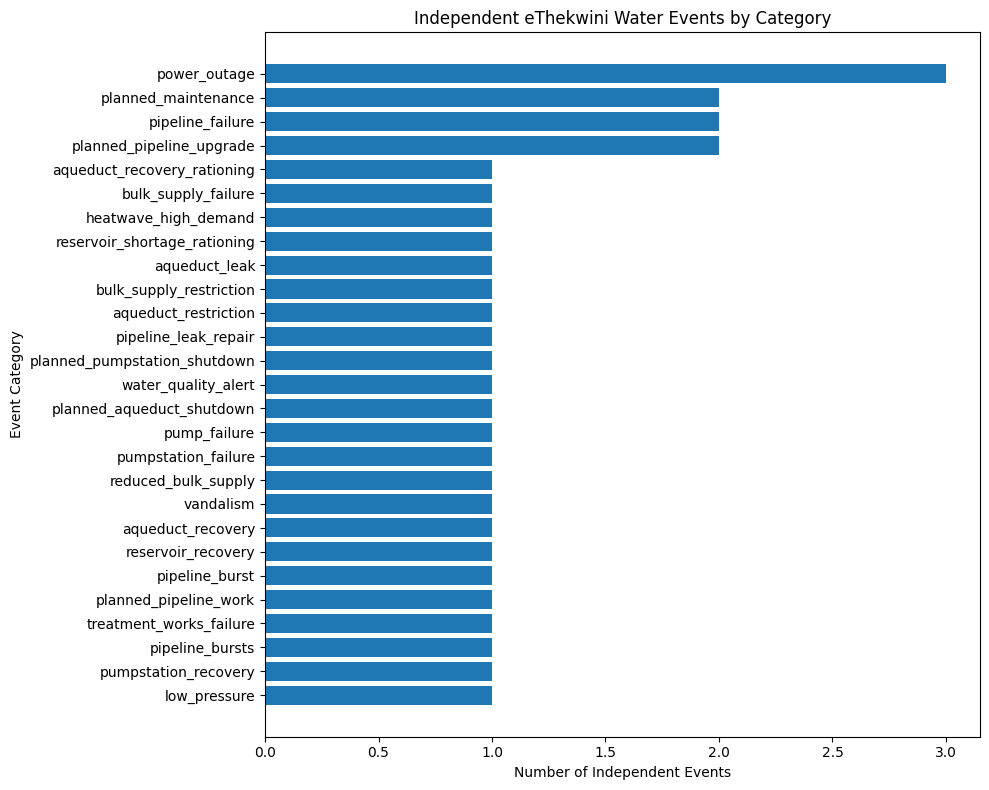

In [4]:
event_level = df[["event_id", "event_date", "event_category", "planned_flag"]].drop_duplicates()

category_counts = event_level["event_category"].value_counts().sort_values()

plt.figure(figsize=(10, 8))
plt.barh(category_counts.index, category_counts.values)
plt.title("Independent eThekwini Water Events by Category")
plt.xlabel("Number of Independent Events")
plt.ylabel("Event Category")
plt.tight_layout()
plt.show()

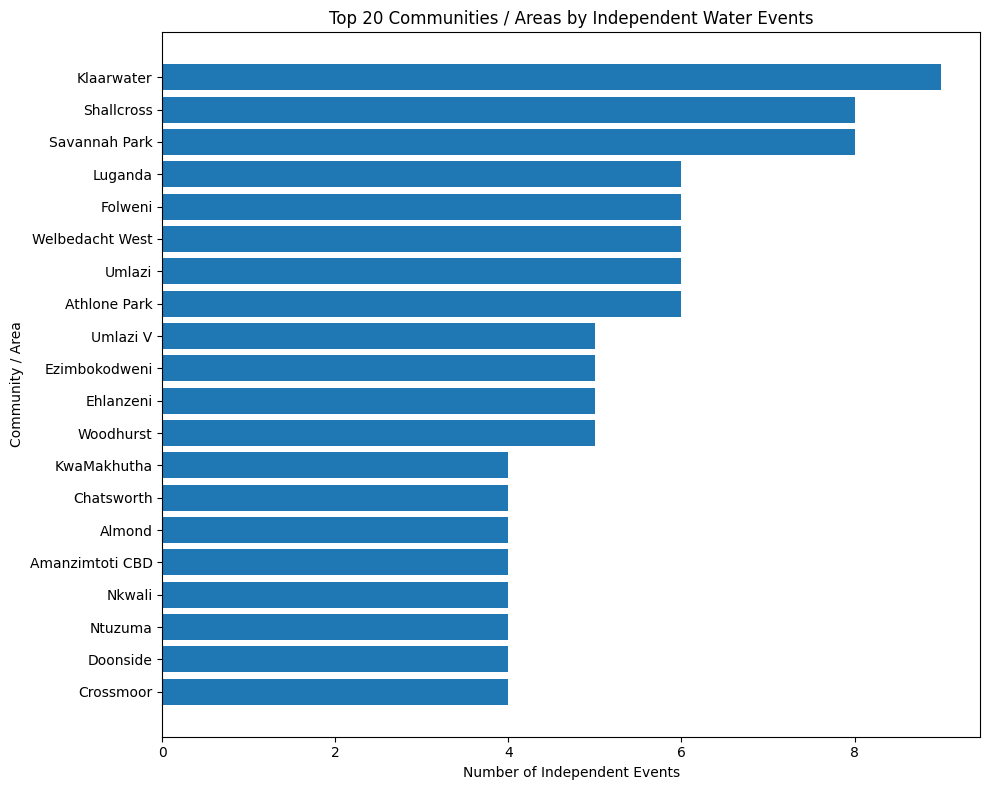

,independent_event_count
affected_area_normalized,
Klaarwater,9
Savannah Park,8
Shallcross,8
Luganda,6
Athlone Park,6
Umlazi,6
Welbedacht West,6
Folweni,6
Woodhurst,5


In [5]:
top_areas = (
    df.groupby("affected_area_normalized")["event_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
      .sort_values()
)

plt.figure(figsize=(10, 8))
plt.barh(top_areas.index, top_areas.values)
plt.title("Top 20 Communities / Areas by Independent Water Events")
plt.xlabel("Number of Independent Events")
plt.ylabel("Community / Area")
plt.tight_layout()
plt.show()

display(top_areas.sort_values(ascending=False).to_frame("independent_event_count"))

## 5. Historical community-risk engineering

In [6]:
dataset_end = df["event_date"].max()

community = (
    df.groupby("affected_area_normalized")
      .agg(
          event_count=("event_id", "nunique"),
          affected_records=("record_id", "count"),
          unplanned_records=("planned_flag", lambda s: int((s == 0).sum())),
          planned_records=("planned_flag", lambda s: int((s == 1).sum())),
          first_event_date=("event_date", "min"),
          last_event_date=("event_date", "max"),
      )
      .reset_index()
      .rename(columns={"affected_area_normalized": "community"})
)

community["days_since_last_event_at_dataset_end"] = (
    dataset_end - community["last_event_date"]
).dt.days

community["unplanned_share"] = (
    community["unplanned_records"] /
    (community["unplanned_records"] + community["planned_records"]).replace(0, np.nan)
).fillna(0)

community["frequency_score"] = community["event_count"].rank(pct=True)
community["recency_score"] = np.exp(
    -community["days_since_last_event_at_dataset_end"] / 365.0
)

community["historical_risk_score"] = (
    0.50 * community["frequency_score"] +
    0.30 * community["recency_score"] +
    0.20 * community["unplanned_share"]
) * 100

q1 = community["historical_risk_score"].quantile(1/3)
q2 = community["historical_risk_score"].quantile(2/3)

community["historical_risk_band"] = pd.cut(
    community["historical_risk_score"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

community = community.sort_values("historical_risk_score", ascending=False)

display(community.head(25))

,community,event_count,affected_records,unplanned_records,planned_records,first_event_date,last_event_date,days_since_last_event_at_dataset_end,unplanned_share,frequency_score,recency_score,historical_risk_score,historical_risk_band
129,Klaarwater,9,9,9,0,2023-02-15,2026-08-31,0,1.000000,1.000000,1.000000,100.000000,High
263,Shallcross,8,8,8,0,2023-07-08,2026-08-31,0,1.000000,0.995522,1.000000,99.776119,High
302,Umlazi,6,6,6,0,2023-10-12,2026-08-31,0,1.000000,0.985075,1.000000,99.253731,High
82,Folweni,6,6,6,0,2023-10-12,2026-08-31,0,1.000000,0.985075,1.000000,99.253731,High
208,Northdene,4,4,4,0,2025-01-15,2026-08-31,0,1.000000,0.922388,1.000000,96.119403,High
43,Chatsworth,4,4,4,0,2023-10-12,2026-08-31,0,1.000000,0.922388,1.000000,96.119403,High
169,Malvern,4,4,4,0,2025-01-15,2026-08-31,0,1.000000,0.922388,1.000000,96.119403,High
243,Queensburgh,4,4,4,0,2023-10-12,2026-07-13,49,1.000000,0.922388,0.874374,92.350636,High
7,Amanzimtoti CBD,4,4,4,0,2023-06-22,2026-06-10,82,1.000000,0.922388,0.798790,90.083095,High
1,Almond,4,4,4,0,2023-06-22,2026-06-10,82,1.000000,0.922388,0.798790,90.083095,High


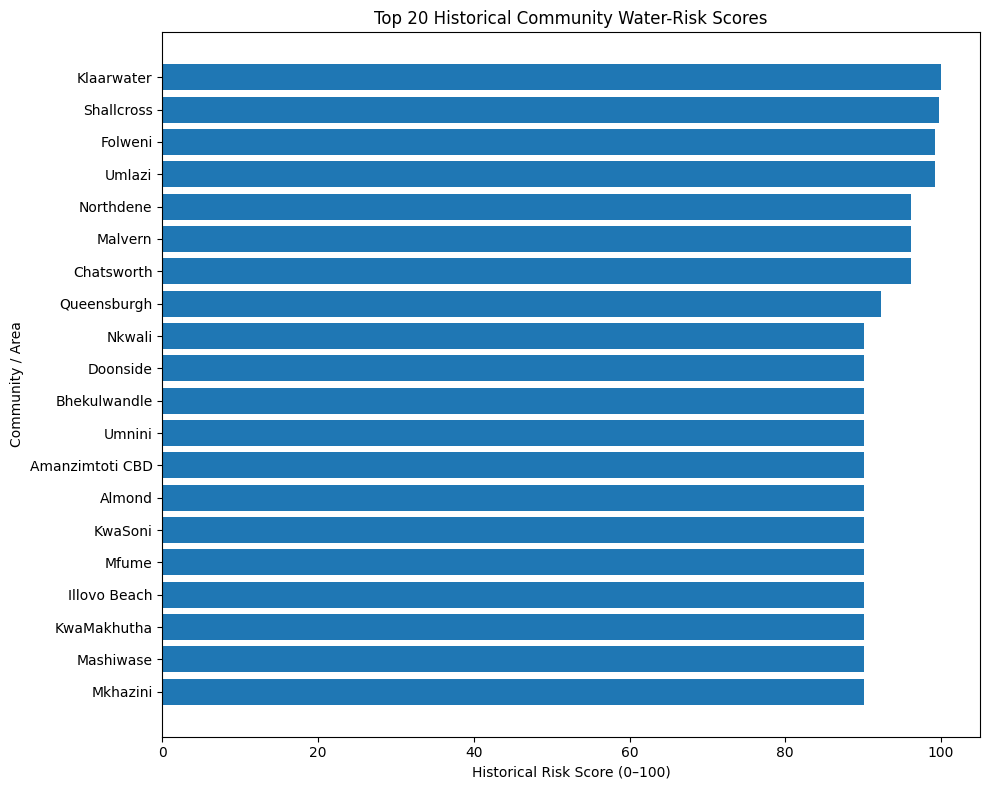

In [7]:
plot_risk = community.head(20).sort_values("historical_risk_score")

plt.figure(figsize=(10, 8))
plt.barh(plot_risk["community"], plot_risk["historical_risk_score"])
plt.title("Top 20 Historical Community Water-Risk Scores")
plt.xlabel("Historical Risk Score (0–100)")
plt.ylabel("Community / Area")
plt.tight_layout()
plt.show()

The historical risk score is an **explainable index**, not a synthetic crisis label:

- 50% frequency percentile
- 30% recency
- 20% unplanned-event share

## 6. Build a complete weekly time series

In [8]:
df["week"] = df["event_date"].dt.to_period("W-SUN").apply(lambda p: p.start_time)

weekly = (
    df.groupby("week")
      .agg(
          affected_area_records=("record_id", "count"),
          incident_count=("event_id", "nunique"),
          unique_areas=("affected_area_normalized", "nunique"),
          unplanned_records=("planned_flag", lambda s: int((s == 0).sum())),
          planned_records=("planned_flag", lambda s: int((s == 1).sum())),
      )
      .reset_index()
)

calendar = pd.DataFrame({
    "week": pd.date_range(df["week"].min(), df["week"].max(), freq="W-MON")
})

weekly = calendar.merge(weekly, on="week", how="left").fillna(0)

for c in weekly.columns[1:]:
    weekly[c] = weekly[c].astype(int)

display(weekly.tail(10))

,week,affected_area_records,incident_count,unique_areas,unplanned_records,planned_records
176,2026-06-29,0,0,0,0,0
177,2026-07-06,0,0,0,0,0
178,2026-07-13,10,1,10,10,0
179,2026-07-20,0,0,0,0,0
180,2026-07-27,3,1,3,3,0
181,2026-08-03,0,0,0,0,0
182,2026-08-10,0,0,0,0,0
183,2026-08-17,0,0,0,0,0
184,2026-08-24,0,0,0,0,0
185,2026-08-31,8,1,8,8,0


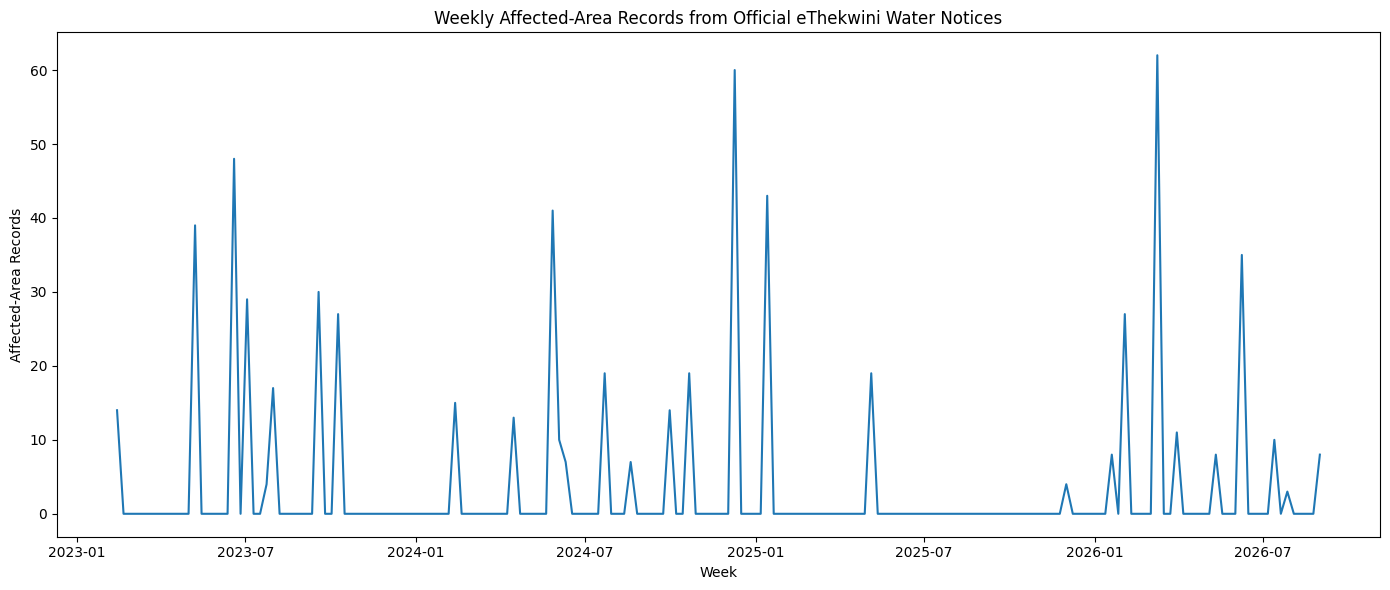

Weeks with zero affected-area records: 83.9%


In [9]:
plt.figure(figsize=(14, 6))
plt.plot(weekly["week"], weekly["affected_area_records"])
plt.title("Weekly Affected-Area Records from Official eThekwini Water Notices")
plt.xlabel("Week")
plt.ylabel("Affected-Area Records")
plt.tight_layout()
plt.show()

zero_share = (weekly["affected_area_records"] == 0).mean()
print(f"Weeks with zero affected-area records: {zero_share:.1%}")

## 7. Time-series feature engineering

In [10]:
model_df = weekly.copy()

# Forecast one week ahead.
model_df["target_next_week"] = model_df["affected_area_records"].shift(-1)

# Current week is known when forecasting the following week.
model_df["current_count"] = model_df["affected_area_records"].astype(float)

for lag in [1, 2, 3, 4, 8, 12]:
    model_df[f"lag_{lag}"] = model_df["affected_area_records"].shift(lag)

for win in [4, 8, 12]:
    history = model_df["affected_area_records"].shift(1)
    model_df[f"roll{win}_mean"] = history.rolling(win).mean()
    model_df[f"roll{win}_std"] = history.rolling(win).std()

model_df["month"] = model_df["week"].dt.month
model_df["sin_month"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["cos_month"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["trend"] = np.arange(len(model_df), dtype=float)

features = [
    "current_count",
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_8", "lag_12",
    "roll4_mean", "roll4_std",
    "roll8_mean", "roll8_std",
    "roll12_mean", "roll12_std",
    "sin_month", "cos_month", "trend",
]

model_df = model_df.dropna().reset_index(drop=True)

print("Supervised observations:", len(model_df))
display(model_df[["week", "target_next_week"] + features].head())

Supervised observations: 173


,week,target_next_week,current_count,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12,roll4_mean,roll4_std,roll8_mean,roll8_std,roll12_mean,roll12_std,sin_month,cos_month,trend
0,2023-05-08,0.0,39.0,0.0,0.0,0.0,0.0,0.0,14.0,0.00,0.0,0.000,0.000000,1.166667,4.041452,5.000000e-01,-0.866025,12.0
1,2023-05-15,0.0,0.0,39.0,0.0,0.0,0.0,0.0,0.0,9.75,19.5,4.875,13.788582,3.250000,11.258330,5.000000e-01,-0.866025,13.0
2,2023-05-22,0.0,0.0,0.0,39.0,0.0,0.0,0.0,0.0,9.75,19.5,4.875,13.788582,3.250000,11.258330,5.000000e-01,-0.866025,14.0
3,2023-05-29,0.0,0.0,0.0,0.0,39.0,0.0,0.0,0.0,9.75,19.5,4.875,13.788582,3.250000,11.258330,5.000000e-01,-0.866025,15.0
4,2023-06-05,0.0,0.0,0.0,0.0,0.0,39.0,0.0,0.0,9.75,19.5,4.875,13.788582,3.250000,11.258330,1.224647e-16,-1.000000,16.0


## 8. Walk-forward validation and three-model comparison

We compare exactly three models:

- **Linear Regression** — simple linear benchmark
- **Decision Tree Regressor** — nonlinear tree-based model
- **Random Forest Regressor** — ensemble of many decision trees

A random train/test split is not used. `TimeSeriesSplit` preserves chronological ordering and evaluates each model on later periods.

### Model selection rule
The final model is selected automatically using the **lowest mean RMSE** across the five time-series folds. RMSE is the primary metric because it penalises large forecasting misses more strongly. MAE and R² are also reported.

In [11]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=4,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=3,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

tscv = TimeSeriesSplit(n_splits=5)

fold_rows = []
oof_predictions = []

for fold, (train_idx, valid_idx) in enumerate(tscv.split(model_df), start=1):
    train = model_df.iloc[train_idx]
    valid = model_df.iloc[valid_idx]

    y_valid = valid["target_next_week"].to_numpy()

    for name, estimator in models.items():
        fitted = clone(estimator)

        fitted.fit(
            train[features],
            train["target_next_week"]
        )

        pred = np.clip(
            fitted.predict(valid[features]),
            0,
            None
        )

        fold_rows.append({
            "model": name,
            "fold": fold,
            "MAE": mean_absolute_error(y_valid, pred),
            "RMSE": mean_squared_error(y_valid, pred) ** 0.5,
            "R2": r2_score(y_valid, pred),
        })

        for week, actual, forecast in zip(
            valid["week"],
            y_valid,
            pred
        ):
            oof_predictions.append({
                "fold": fold,
                "week": week,
                "model": name,
                "actual": actual,
                "forecast": forecast,
            })

fold_metrics = pd.DataFrame(fold_rows)

leaderboard = (
    fold_metrics
    .groupby("model", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
        std_RMSE=("RMSE", "std"),
        mean_R2=("R2", "mean"),
    )
    .sort_values(["mean_RMSE", "mean_MAE"])
    .reset_index(drop=True)
)

display(leaderboard.round(3))

,model,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2
0,Random Forest,8.255,3.256,11.380,3.243,-3.077
1,Decision Tree,8.879,5.223,12.011,4.100,-3.396
2,Linear Regression,7.547,3.715,12.214,4.558,-2.009


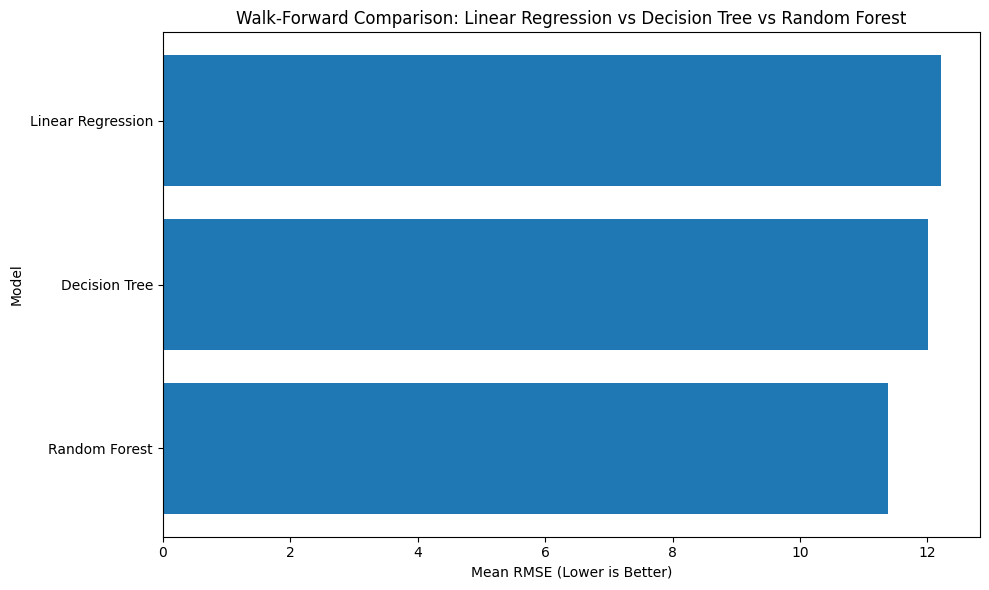

In [12]:
plot_board = leaderboard.sort_values("mean_RMSE", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_board["model"],
    plot_board["mean_RMSE"]
)
plt.title("Walk-Forward Comparison: Linear Regression vs Decision Tree vs Random Forest")
plt.xlabel("Mean RMSE (Lower is Better)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 9. Automatically select the best model

The final model is selected using the **lowest mean RMSE** across the walk-forward validation folds.

Why RMSE? Water-service data can contain sharp disruption spikes. RMSE gives larger mistakes more weight, so it is useful when we want the selected model to avoid very large forecasting errors.

In [13]:
best_row = (
    leaderboard
    .sort_values(["mean_RMSE", "mean_MAE"])
    .iloc[0]
)

best_model_name = best_row["model"]

print("SELECTED MODEL:", best_model_name)
print("Mean RMSE:", round(best_row["mean_RMSE"], 3))
print("Mean MAE:", round(best_row["mean_MAE"], 3))
print("Mean R²:", round(best_row["mean_R2"], 3))

print("\nFull three-model ranking:")
display(
    leaderboard[
        ["model", "mean_RMSE", "mean_MAE", "mean_R2"]
    ].round(3)
)

if best_model_name == "Random Forest":
    print(
        "\nRandom Forest is selected as the final AquaSafe model "
        "because it achieved the lowest average RMSE."
    )
else:
    print(
        f"\n{best_model_name} achieved the lowest average RMSE and is "
        "therefore selected objectively as the final model."
    )

SELECTED MODEL: Random Forest
Mean RMSE: 11.38
Mean MAE: 8.255
Mean R²: -3.077

Full three-model ranking:


,model,mean_RMSE,mean_MAE,mean_R2
0,Random Forest,11.380,8.255,-3.077
1,Decision Tree,12.011,8.879,-3.396
2,Linear Regression,12.214,7.547,-2.009



Random Forest is selected as the final AquaSafe model because it achieved the lowest average RMSE.


## 10. Out-of-fold performance of the selected model

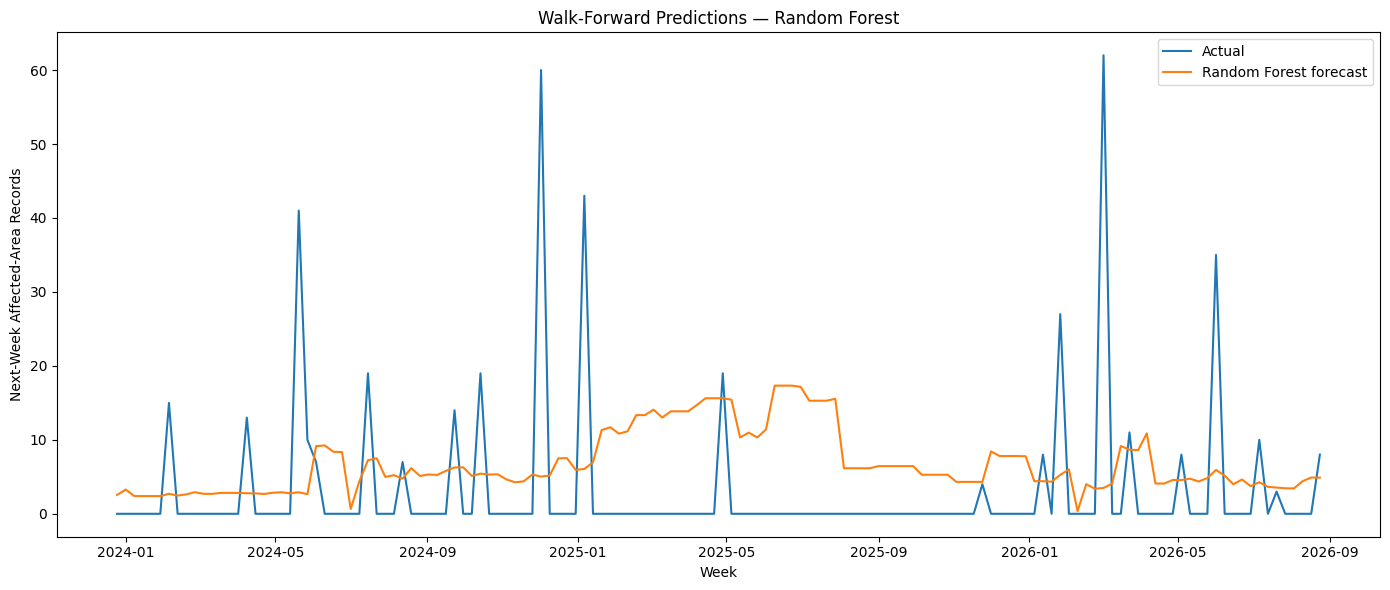

In [14]:
oof = pd.DataFrame(oof_predictions)

best_oof = (
    oof[oof["model"] == best_model_name]
    .sort_values("week")
)

plt.figure(figsize=(14, 6))
plt.plot(
    best_oof["week"],
    best_oof["actual"],
    label="Actual"
)
plt.plot(
    best_oof["week"],
    best_oof["forecast"],
    label=f"{best_model_name} forecast"
)

plt.title(
    f"Walk-Forward Predictions — {best_model_name}"
)
plt.xlabel("Week")
plt.ylabel("Next-Week Affected-Area Records")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Fit and save the selected final model

In [15]:
best_model = clone(models[best_model_name])

best_model.fit(
    model_df[features],
    model_df["target_next_week"]
)

bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "features": features,
    "selection_metric": "mean_RMSE",
    "mean_RMSE": float(best_row["mean_RMSE"]),
    "mean_MAE": float(best_row["mean_MAE"]),
    "training_end_week": str(model_df["week"].max().date()),
    "dataset_end_date": str(df["event_date"].max().date()),
}

joblib.dump(
    bundle,
    "aquasafe_best_selected_model.joblib"
)

print(
    "Saved final model:",
    best_model_name,
    "-> aquasafe_best_selected_model.joblib"
)

Saved final model: Random Forest -> aquasafe_best_selected_model.joblib


## 12. Explain the selected model

,feature,importance
15,trend,0.2497
4,lag_4,0.1081
6,lag_12,0.0943
14,cos_month,0.0863
11,roll12_mean,0.0730
13,sin_month,0.0708
12,roll12_std,0.0646
10,roll8_std,0.0630
8,roll4_std,0.0573
9,roll8_mean,0.0405


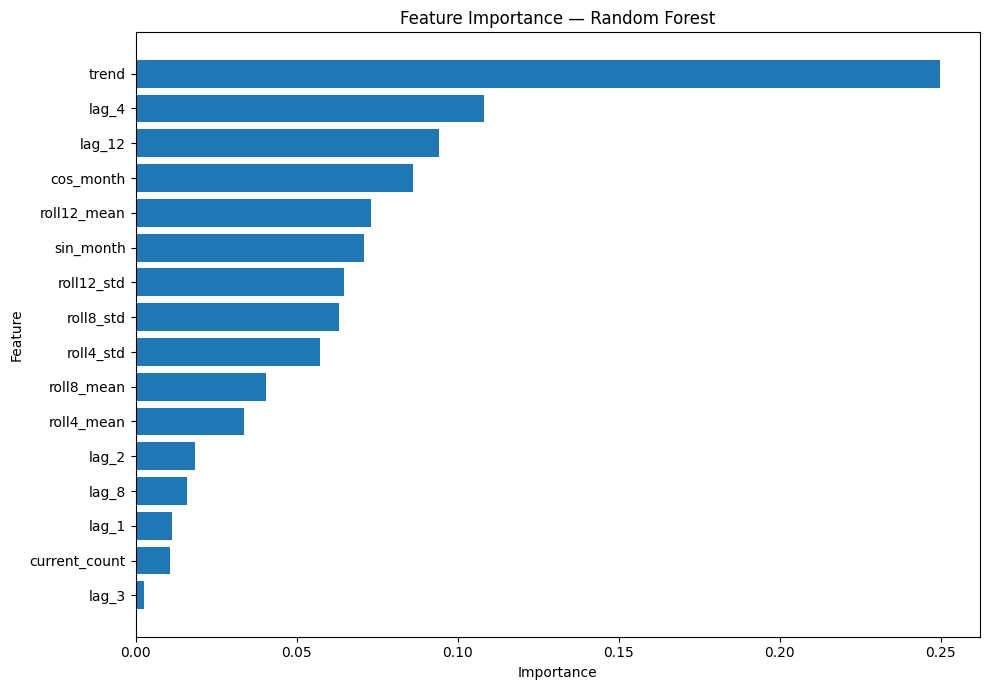

In [16]:
if hasattr(best_model, "feature_importances_"):
    importance = (
        pd.DataFrame({
            "feature": features,
            "importance": best_model.feature_importances_
        })
        .sort_values("importance", ascending=False)
    )

    display(importance.round(4))

    plot_imp = importance.sort_values("importance")

    plt.figure(figsize=(10, 7))
    plt.barh(
        plot_imp["feature"],
        plot_imp["importance"]
    )
    plt.title(
        f"Feature Importance — {best_model_name}"
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, "coef_"):
    coefficients = (
        pd.DataFrame({
            "feature": features,
            "coefficient": best_model.coef_
        })
        .sort_values("coefficient")
    )

    display(coefficients.round(4))

    plt.figure(figsize=(10, 7))
    plt.barh(
        coefficients["feature"],
        coefficients["coefficient"]
    )
    plt.title(
        f"Feature Coefficients — {best_model_name}"
    )
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 13. Recursive 12-week forecasting using the selected model

,week_start,forecast_affected_area_records
0,2026-09-07,4.824
1,2026-09-14,5.775
2,2026-09-21,3.773
3,2026-09-28,5.656
4,2026-10-05,3.370
5,2026-10-12,3.639
6,2026-10-19,3.039
7,2026-10-26,2.897
8,2026-11-02,4.901
9,2026-11-09,4.717


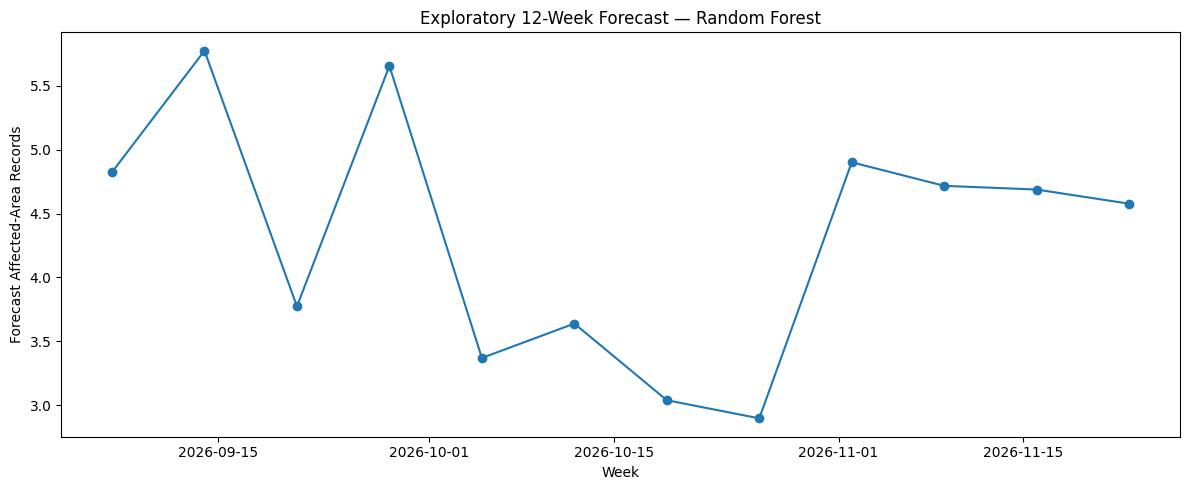

In [17]:
history = weekly[["week", "affected_area_records"]].copy()
future_rows = []

for step in range(12):
    vals = history["affected_area_records"].to_numpy(dtype=float)
    next_week = history["week"].iloc[-1] + pd.Timedelta(weeks=1)

    row = {
        "current_count": vals[-1],
        "lag_1": vals[-2],
        "lag_2": vals[-3],
        "lag_3": vals[-4],
        "lag_4": vals[-5],
        "lag_8": vals[-9],
        "lag_12": vals[-13],
        "roll4_mean": vals[-4:].mean(),
        "roll4_std": vals[-4:].std(ddof=1),
        "roll8_mean": vals[-8:].mean(),
        "roll8_std": vals[-8:].std(ddof=1),
        "roll12_mean": vals[-12:].mean(),
        "roll12_std": vals[-12:].std(ddof=1),
        "sin_month": np.sin(2 * np.pi * next_week.month / 12),
        "cos_month": np.cos(2 * np.pi * next_week.month / 12),
        "trend": float(len(weekly) + step),
    }

    forecast = float(np.clip(
        best_model.predict(pd.DataFrame([row])[features])[0],
        0,
        None
    ))

    future_rows.append({
        "week_start": next_week,
        "forecast_affected_area_records": forecast
    })

    history = pd.concat([
        history,
        pd.DataFrame({
            "week": [next_week],
            "affected_area_records": [forecast]
        })
    ], ignore_index=True)

future = pd.DataFrame(future_rows)

display(future.round(3))

plt.figure(figsize=(12, 5))
plt.plot(future["week_start"], future["forecast_affected_area_records"], marker="o")
plt.title(f"Exploratory 12-Week Forecast — {best_model_name}")
plt.xlabel("Week")
plt.ylabel("Forecast Affected-Area Records")
plt.tight_layout()
plt.show()

## 14. 7-, 14-, and 30-day forecast summary

,horizon,forecast_affected_area_records
0,Next 7 days,4.824
1,Next 14 days,10.598
2,Next 30 days,20.990


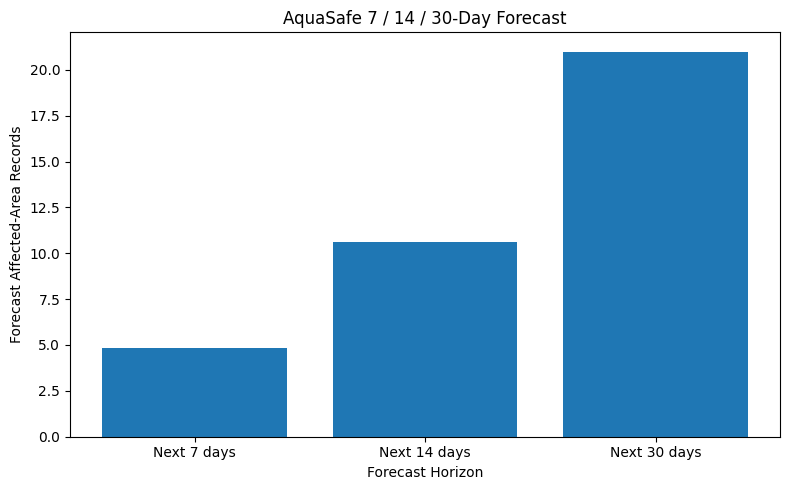

In [18]:
vals = future["forecast_affected_area_records"].to_numpy(dtype=float)

forecast_7 = vals[0]
forecast_14 = vals[:2].sum()

# Four full forecast weeks + 2/7 of week 5 gives an approximate 30-day total.
forecast_30 = vals[:4].sum() + (2/7) * vals[4]

horizon_forecast = pd.DataFrame({
    "horizon": ["Next 7 days", "Next 14 days", "Next 30 days"],
    "forecast_affected_area_records": [
        forecast_7,
        forecast_14,
        forecast_30
    ]
})

display(horizon_forecast.round(3))

plt.figure(figsize=(8, 5))
plt.bar(
    horizon_forecast["horizon"],
    horizon_forecast["forecast_affected_area_records"]
)
plt.title("AquaSafe 7 / 14 / 30-Day Forecast")
plt.ylabel("Forecast Affected-Area Records")
plt.xlabel("Forecast Horizon")
plt.tight_layout()
plt.show()

## 15. Real eThekwini suburb map

This section queries the official eThekwini suburb polygon layer when internet access is available. It matches only names that genuinely correspond to official suburb labels. Unmatched roads, hospitals, schemes, villages, or other locality descriptions are **not force-assigned**.

In [19]:
# The real-map code is included but disabled during automated notebook execution.
# Set RUN_LIVE_MAP = True when running locally with internet access.
RUN_LIVE_MAP = False

if RUN_LIVE_MAP:
    import requests
    import geopandas as gpd
    import re

    SUBURBS_QUERY = (
        "https://gis.durban.gov.za/server/rest/services/"
        "WebViewers/EXT_Cadastral/MapServer/19/query"
    )

    params = {
        "where": "1=1",
        "outFields": "OBJECTID,SUBURB,SUBURB_ID,DISTRICT",
        "returnGeometry": "true",
        "outSR": "4326",
        "f": "geojson",
    }

    response = requests.get(SUBURBS_QUERY, params=params, timeout=20)
    response.raise_for_status()
    geojson = response.json()

    suburbs = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")

    def normalise_name(value):
        value = str(value).upper().strip()
        return re.sub(r"[^A-Z0-9]+", "", value)

    suburbs["join_name"] = suburbs["SUBURB"].map(normalise_name)
    community["join_name"] = community["community"].map(normalise_name)

    map_data = suburbs.merge(
        community[["community", "join_name", "historical_risk_score", "historical_risk_band"]],
        on="join_name", how="left"
    )

    print("Official suburb polygons:", len(suburbs))
    print("Matched polygons:", map_data["historical_risk_score"].notna().sum())

    fig, ax = plt.subplots(figsize=(12, 12))
    map_data.plot(
        column="historical_risk_score", legend=True, ax=ax,
        missing_kwds={"label": "No matched event history"}
    )
    ax.set_title("eThekwini Historical Community Water-Risk Map")
    ax.set_axis_off()
    plt.show()
else:
    print("Live eThekwini map skipped during automated execution. Set RUN_LIVE_MAP = True locally.")

Live eThekwini map skipped during automated execution. Set RUN_LIVE_MAP = True locally.


## 16. Save ML lifecycle outputs

In [20]:
community.to_csv(
    "AquaSafe_Upgraded_Community_Risk_Snapshot.csv",
    index=False
)

weekly.to_csv(
    "AquaSafe_Upgraded_Weekly_System_Series.csv",
    index=False
)

leaderboard.to_csv(
    "AquaSafe_3_Model_Leaderboard.csv",
    index=False
)

future.to_csv(
    "AquaSafe_RF_12_Week_Forecast.csv",
    index=False
)

horizon_forecast.to_csv(
    "AquaSafe_RF_Forecast_7_14_30_Days.csv",
    index=False
)

print("Saved updated AquaSafe outputs.")
print("Final selected model:", best_model_name)

Saved updated AquaSafe outputs.
Final selected model: Random Forest


## 17. Monitoring and retraining plan

A production ML lifecycle does not stop after training.

**Data monitoring**
- Add new official water events as they become available.
- Check missing dates, duplicate event IDs, new event categories, and new community names.
- Track changes in the weekly activity distribution.

**Performance monitoring**
- Compare each new forecast against the observed next-week value.
- Recalculate MAE, RMSE and R².
- Re-run the same comparison between Linear Regression, Decision Tree and Random Forest.

**Retraining trigger**
- Retrain when a meaningful block of new independent events has accumulated.
- Keep the same time-aware validation process so the model comparison remains fair.

## Final interpretation
This notebook compares exactly **Linear Regression, Decision Tree Regression and Random Forest Regression** and automatically selects the best model using mean RMSE.

The forecast remains **exploratory** because the source is a sparse public-notice dataset rather than the complete operational municipal fault log.